<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/fluidflow/natural_gas_pipeline_linepack.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Natural-gas pipeline linepack and operational flexibility

This notebook combines NeqSim real-gas properties with the native
`PipeBeggsAndBrills` pipeline model to quantify pressure loss, gas inventory,
pack/unpack flexibility, and operating margins in a long transmission line.

The example is an educational screening study. All pressures are absolute,
and the calculation is not a substitute for a validated transient pipeline
model or an operating procedure.

## Learning objectives

After completing the notebook, you can:

1. build a reproducible dry natural-gas fluid with the SRK equation of state;
2. calculate density, compressibility factor, and viscosity across a pressure range;
3. generate pressure profiles with NeqSim's native pipeline equipment;
4. integrate the pressure-dependent gas density to obtain linepack;
5. translate working linepack into hours of demand support;
6. simulate a pack/unpack event with an auditable mass balance; and
7. distinguish a lumped operational screen from a full transient hydraulic model.

## Engineering case and assumptions

The case represents a horizontal, dry-gas transmission pipeline:

| Quantity | Value |
|---|---:|
| Length | 100 km |
| Internal diameter | 0.60 m |
| Absolute roughness | 0.015 mm |
| Gas temperature | 15 °C, isothermal |
| Inlet pressure | 100 bara |
| Base mass flow | 100 kg/s |
| Minimum outlet pressure | 70 bara |
| Minimum lumped mean pressure | 80 bara |
| Maximum lumped mean pressure | 105 bara |
| Standard-volume reference | 1.01325 bara and 15 °C |

The SRK equation of state with the classic mixing rule is used. The gas is
single phase in the demonstrated pressure range. Elevation, heat transfer,
composition fronts, compressor dynamics, regulator dynamics, acoustic waves,
and leak or rupture events are outside the model boundary.

In [1]:
import subprocess
import sys

install_command = [
    sys.executable,
    "-m",
    "pip",
    "install",
    "--quiet",
    "--upgrade",
    "--no-cache-dir",
    "--disable-pip-version-check",
    "neqsim",
    "matplotlib",
    "pandas",
]

installation = subprocess.run(
    install_command,
    check=False,
    capture_output=True,
    text=True,
)

if installation.returncode != 0:
    print(installation.stdout)
    print(installation.stderr)
    raise RuntimeError("The public PyPI installation failed.")

print("Public PyPI dependencies are available.")

Public PyPI dependencies are available.


In [2]:
from functools import lru_cache
from importlib.metadata import version

import jpype
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from neqsim import jneqsim

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(precision=4, suppress=True)

NEQSIM_VERSION = version("neqsim")
PYTHON_VERSION = sys.version.split()[0]
JAVA_VERSION = str(jpype.JClass("java.lang.System").getProperty("java.version"))

runtime_table = pd.DataFrame(
    {
        "Runtime": ["NeqSim", "Python", "Java"],
        "Version": [NEQSIM_VERSION, PYTHON_VERSION, JAVA_VERSION],
    }
)
display(runtime_table)

,Runtime,Version
0,NeqSim,3.16.0
1,Python,3.12.13
2,Java,17.0.19


## 1. Define the natural-gas fluid

The composition is on a mole-fraction basis and sums to one. SRK is a
practical cubic equation of state for hydrocarbon-gas pipeline screening.
The reusable template is cloned before each thermodynamic or pipeline
calculation so that scenario runs do not share mutable state.

In [3]:
composition = {
    "methane": 0.900,
    "ethane": 0.060,
    "propane": 0.015,
    "nitrogen": 0.020,
    "CO2": 0.005,
}

temperature_k = 288.15
inlet_pressure_bara = 100.0

fluid_template = jneqsim.thermo.system.SystemSrkEos(
    temperature_k,
    inlet_pressure_bara,
)

for component_name, mole_fraction in composition.items():
    fluid_template.addComponent(component_name, mole_fraction)

fluid_template.setMixingRule("classic")
fluid_template.init(0)

composition_sum = sum(composition.values())
composition_table = pd.DataFrame(
    {
        "Component": list(composition),
        "Mole fraction": list(composition.values()),
    }
)

display(composition_table)
print(f"Composition sum: {composition_sum:.6f}")

Composition sum: 1.000000


,Component,Mole fraction
0,methane,0.900
1,ethane,0.060
2,propane,0.015
3,nitrogen,0.020
4,CO2,0.005


At each pressure, NeqSim performs a TP flash and initializes physical
properties. The returned density $\rho$, compressibility factor $Z$, dynamic
viscosity $\mu$, molar mass $M_\mathrm{w}$, and phase count are used by the
pipeline and inventory calculations.

In [4]:
@lru_cache(maxsize=512)
def gas_properties(pressure_bara):
    fluid = fluid_template.clone()
    fluid.setTemperature(temperature_k, "K")
    fluid.setPressure(float(pressure_bara), "bara")

    operations = jneqsim.thermodynamicoperations.ThermodynamicOperations(fluid)
    operations.TPflash()
    fluid.initProperties()

    return {
        "pressure_bara": float(pressure_bara),
        "density_kg_m3": float(fluid.getDensity("kg/m3")),
        "z_factor": float(fluid.getZ()),
        "viscosity_pa_s": float(fluid.getViscosity("kg/msec")),
        "molar_mass_kg_mol": float(fluid.getMolarMass()),
        "phase_count": int(fluid.getNumberOfPhases()),
    }


property_pressures = np.linspace(60.0, 110.0, 11)
property_rows = [gas_properties(float(pressure)) for pressure in property_pressures]
property_table = pd.DataFrame(property_rows)

display(
    property_table.rename(
        columns={
            "pressure_bara": "Pressure [bara]",
            "density_kg_m3": "Density [kg/m³]",
            "z_factor": "Z [-]",
            "viscosity_pa_s": "Viscosity [Pa s]",
            "molar_mass_kg_mol": "Molar mass [kg/mol]",
            "phase_count": "Phases [-]",
        }
    ).round(6)
)

,Pressure [bara],Density [kg/m³],Z [-],Viscosity [Pa s],Molar mass [kg/mol],Phases [-]
0,60.0,50.981261,0.870949,0.000012,0.017685,1
1,65.0,55.840006,0.861639,0.000013,0.017685,1
2,70.0,60.781571,0.852689,0.000013,0.017685,1
3,75.0,65.799595,0.844135,0.000013,0.017685,1
4,80.0,70.886392,0.836009,0.000013,0.017685,1
5,85.0,76.032963,0.828347,0.000014,0.017685,1
6,90.0,81.229050,0.821182,0.000014,0.017685,1
7,95.0,86.463264,0.814542,0.000014,0.017685,1
8,100.0,91.723260,0.808455,0.000014,0.017685,1
9,105.0,96.995978,0.802944,0.000015,0.017685,1


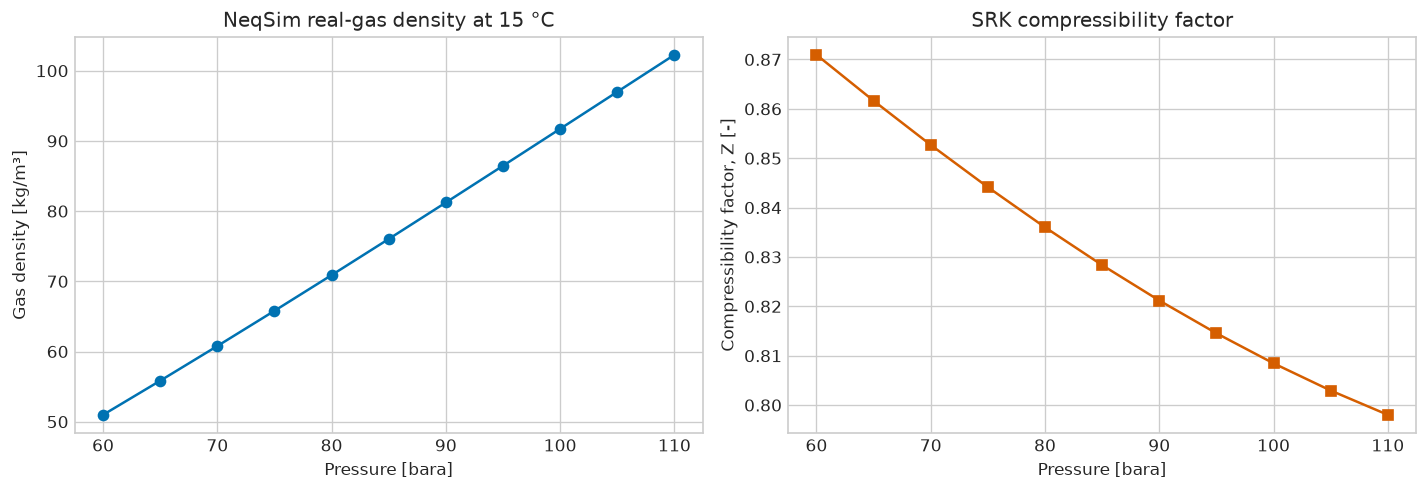

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].plot(
    property_table["pressure_bara"],
    property_table["density_kg_m3"],
    marker="o",
    color="#0072B2",
)
axes[0].set(
    xlabel="Pressure [bara]",
    ylabel="Gas density [kg/m³]",
    title="NeqSim real-gas density at 15 °C",
)

axes[1].plot(
    property_table["pressure_bara"],
    property_table["z_factor"],
    marker="s",
    color="#D55E00",
)
axes[1].set(
    xlabel="Pressure [bara]",
    ylabel="Compressibility factor, Z [-]",
    title="SRK compressibility factor",
)

fig.tight_layout()
plt.show()

### Independent density identity

For a real gas, the equation-of-state identity is

$$

\rho = \frac{p M_\mathrm{w}}{Z R T}

$$

where $p$ is absolute pressure in Pa, $M_\mathrm{w}$ is molar mass in
kg/mol, $R$ is the universal gas constant in J/(mol K), and $T$ is absolute
temperature in K. NeqSim applies a component volume correction to the SRK
phase by default, while this identity uses the uncorrected cubic-EOS volume.
A sub-percent difference is therefore expected and provides an independent
unit and magnitude check on the NeqSim density retrieval.

In [6]:
gas_constant = 8.314462618
density_check_rows = []

for row in property_rows:
    pressure_pa = row["pressure_bara"] * 1.0e5
    density_identity = (
        pressure_pa
        * row["molar_mass_kg_mol"]
        / (row["z_factor"] * gas_constant * temperature_k)
    )
    relative_error = abs(
        density_identity - row["density_kg_m3"]
    ) / row["density_kg_m3"]

    density_check_rows.append(
        {
            "Pressure [bara]": row["pressure_bara"],
            "NeqSim density [kg/m³]": row["density_kg_m3"],
            "EOS identity [kg/m³]": density_identity,
            "Relative error [-]": relative_error,
        }
    )

density_check_table = pd.DataFrame(density_check_rows)
display(density_check_table.round(10))

maximum_density_identity_error = density_check_table[
    "Relative error [-]"
].max()
print(
    "Maximum volume-corrected density vs. uncorrected EOS difference: "
    f"{maximum_density_identity_error:.3%}"
)

Maximum volume-corrected density vs. uncorrected EOS difference: 0.510%


,Pressure [bara],NeqSim density [kg/m³],EOS identity [kg/m³],Relative error [-]
0,60.0,50.981261,50.851375,0.002548
1,65.0,55.840006,55.684220,0.002790
2,70.0,60.781571,60.597039,0.003036
3,75.0,65.799595,65.583390,0.003286
4,80.0,70.886392,70.635530,0.003539
5,85.0,76.032963,75.744426,0.003795
6,90.0,81.229050,80.899815,0.004053
7,95.0,86.463264,86.090329,0.004313
8,100.0,91.723260,91.303680,0.004574
9,105.0,96.995978,96.526896,0.004836


## 2. Native NeqSim pipeline pressure profiles

For horizontal single-phase flow, a useful independent form of the
Darcy-Weisbach pressure-gradient screen is

$$

\frac{dp}{dx}
=
-\frac{f_\mathrm{D}}{2D}
\frac{\dot{m}^{\,2}}{\rho A^2}

$$

where $f_\mathrm{D}$ is the Darcy friction factor, $D$ is internal diameter,
$\dot{m}$ is mass flow, $\rho$ is local density, and $A$ is flow area.

The actual pressure profiles below are calculated with NeqSim's
`PipeBeggsAndBrills` equipment using 100 increments and isothermal operation.
The independent equation is used later only as a magnitude check.

In [7]:
pipeline_length_m = 100_000.0
pipeline_diameter_m = 0.60
absolute_roughness_m = 1.5e-5
number_of_increments = 100
flow_area_m2 = np.pi * pipeline_diameter_m**2 / 4.0


def run_pipeline_case(mass_flow_kg_s):
    feed_fluid = fluid_template.clone()
    feed_fluid.setTemperature(temperature_k, "K")
    feed_fluid.setPressure(inlet_pressure_bara, "bara")
    feed_fluid.setTotalFlowRate(float(mass_flow_kg_s), "kg/sec")

    feed_stream = jneqsim.process.equipment.stream.Stream(
        f"feed {mass_flow_kg_s:.0f} kg/s",
        feed_fluid,
    )
    feed_stream.run()

    pipeline = jneqsim.process.equipment.pipeline.PipeBeggsAndBrills(
        f"100 km pipeline {mass_flow_kg_s:.0f} kg/s",
        feed_stream,
    )
    pipeline.setDiameter(pipeline_diameter_m)
    pipeline.setLength(pipeline_length_m)
    pipeline.setPipeWallRoughness(absolute_roughness_m)
    pipeline.setNumberOfIncrements(number_of_increments)
    pipeline.setRunIsothermal(True)
    pipeline.setConstantSurfaceTemperature(temperature_k, "K")
    pipeline.run()

    pressure_profile = np.asarray(
        list(pipeline.getPressureProfile()),
        dtype=float,
    )
    distance_m = np.linspace(
        0.0,
        pipeline_length_m,
        pressure_profile.size,
    )

    return {
        "mass_flow_kg_s": float(mass_flow_kg_s),
        "distance_m": distance_m,
        "pressure_bara": pressure_profile,
        "outlet_pressure_bara": float(pipeline.getOutletPressure()),
        "pressure_drop_bar": float(pipeline.getPressureDrop()),
        "outlet_velocity_m_s": float(pipeline.getMixtureVelocity()),
        "flow_regime": str(pipeline.getFlowRegime()),
        "pipeline": pipeline,
    }

In [8]:
screening_flows_kg_s = np.arange(40.0, 180.0, 20.0)
pipeline_cases = {
    float(flow): run_pipeline_case(float(flow))
    for flow in screening_flows_kg_s
}

minimum_outlet_pressure_bara = 70.0
maximum_velocity_m_s = 15.0

pipeline_table = pd.DataFrame(
    [
        {
            "Mass flow [kg/s]": case["mass_flow_kg_s"],
            "Outlet pressure [bara]": case["outlet_pressure_bara"],
            "Pressure drop [bar]": case["pressure_drop_bar"],
            "Outlet velocity [m/s]": case["outlet_velocity_m_s"],
            "Flow regime": case["flow_regime"],
            "Within screen": (
                case["outlet_pressure_bara"]
                >= minimum_outlet_pressure_bara
                and case["outlet_velocity_m_s"] <= maximum_velocity_m_s
            ),
        }
        for case in pipeline_cases.values()
    ]
)

display(pipeline_table.round(3))

,Mass flow [kg/s],Outlet pressure [bara],Pressure drop [bar],Outlet velocity [m/s],Flow regime,Within screen
0,40.0,98.148,1.852,1.568,SINGLE_PHASE,True
1,60.0,95.881,4.119,2.402,SINGLE_PHASE,True
2,80.0,92.659,7.341,3.302,SINGLE_PHASE,True
3,100.0,88.391,11.609,4.307,SINGLE_PHASE,True
4,120.0,82.929,17.071,5.479,SINGLE_PHASE,True
5,140.0,76.040,23.960,6.928,SINGLE_PHASE,True
6,160.0,67.313,32.687,8.885,SINGLE_PHASE,False


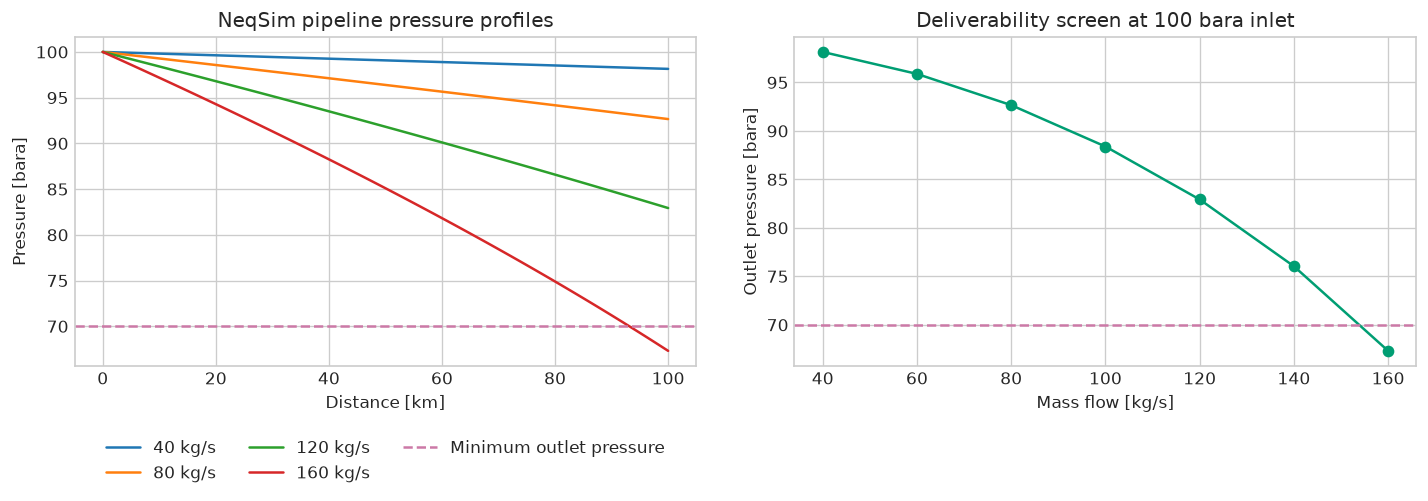

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))

for flow in [40.0, 80.0, 120.0, 160.0]:
    case = pipeline_cases[flow]
    axes[0].plot(
        case["distance_m"] / 1000.0,
        case["pressure_bara"],
        label=f"{flow:.0f} kg/s",
    )

axes[0].axhline(
    minimum_outlet_pressure_bara,
    color="#CC79A7",
    linestyle="--",
    label="Minimum outlet pressure",
)
axes[0].set(
    xlabel="Distance [km]",
    ylabel="Pressure [bara]",
    title="NeqSim pipeline pressure profiles",
)
axes[0].legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=3,
    frameon=False,
)

axes[1].plot(
    pipeline_table["Mass flow [kg/s]"],
    pipeline_table["Outlet pressure [bara]"],
    marker="o",
    color="#009E73",
)
axes[1].axhline(
    minimum_outlet_pressure_bara,
    color="#CC79A7",
    linestyle="--",
)
axes[1].set(
    xlabel="Mass flow [kg/s]",
    ylabel="Outlet pressure [bara]",
    title="Deliverability screen at 100 bara inlet",
)

fig.tight_layout()
plt.show()

The pressure profiles fall monotonically from inlet to outlet. At fixed inlet
pressure, increasing throughput consumes more pressure margin. The discrete
screen identifies the highest demonstrated flow that meets both the outlet
pressure and velocity limits; it is not an optimized capacity certificate.

In [10]:
base_flow_kg_s = 100.0
base_case = pipeline_cases[base_flow_kg_s]
base_mean_pressure_bara = (
    inlet_pressure_bara + base_case["outlet_pressure_bara"]
) / 2.0
base_properties = gas_properties(base_mean_pressure_bara)

base_velocity_m_s = (
    base_flow_kg_s
    / (base_properties["density_kg_m3"] * flow_area_m2)
)
base_reynolds_number = (
    base_flow_kg_s
    * pipeline_diameter_m
    / (flow_area_m2 * base_properties["viscosity_pa_s"])
)
swamee_jain_friction_factor = 0.25 / (
    np.log10(
        absolute_roughness_m / (3.7 * pipeline_diameter_m)
        + 5.74 / base_reynolds_number**0.9
    )
    ** 2
)
darcy_pressure_drop_bar = (
    swamee_jain_friction_factor
    * pipeline_length_m
    / pipeline_diameter_m
    * base_properties["density_kg_m3"]
    * base_velocity_m_s**2
    / 2.0
    / 1.0e5
)
darcy_relative_difference = abs(
    darcy_pressure_drop_bar - base_case["pressure_drop_bar"]
) / base_case["pressure_drop_bar"]

darcy_check = pd.DataFrame(
    {
        "Quantity": [
            "NeqSim pressure drop [bar]",
            "Independent Darcy estimate [bar]",
            "Relative difference [-]",
            "Mean-density Reynolds number [-]",
            "Swamee-Jain Darcy factor [-]",
        ],
        "Value": [
            base_case["pressure_drop_bar"],
            darcy_pressure_drop_bar,
            darcy_relative_difference,
            base_reynolds_number,
            swamee_jain_friction_factor,
        ],
    }
)
display(darcy_check.round(6))

,Quantity,Value
0,NeqSim pressure drop [bar],1.160939e+01
1,Independent Darcy estimate [bar],1.189407e+01
2,Relative difference [-],2.452200e-02
3,Mean-density Reynolds number [-],1.515034e+07
4,Swamee-Jain Darcy factor [-],9.769000e-03


## 3. Calculate linepack

Linepack is the gas mass stored inside the pipeline. For internal area $A$
and a pressure-dependent density profile, the inventory is

$$

M
=
\int_0^L \rho\!\left(p(x), T, \mathbf{x}\right) A\,dx

$$

where $L$ is pipeline length and $\mathbf{x}$ denotes gas composition. The
notebook evaluates density with NeqSim at every pressure-profile node and
integrates numerically.

Standard volume is reported at 1.01325 bara and 15 °C:
$V_\mathrm{s}=M/\rho_\mathrm{s}$. This base condition must always accompany a
quoted standard volume.

In [11]:
standard_pressure_bara = 1.01325
standard_density_kg_m3 = gas_properties(
    standard_pressure_bara
)["density_kg_m3"]


def integrate_profile_inventory(case):
    densities_kg_m3 = np.asarray(
        [
            gas_properties(float(pressure))["density_kg_m3"]
            for pressure in case["pressure_bara"]
        ]
    )
    inventory_kg = (
        np.trapezoid(densities_kg_m3, case["distance_m"])
        * flow_area_m2
    )

    return {
        "densities_kg_m3": densities_kg_m3,
        "inventory_kg": inventory_kg,
        "standard_volume_sm3": inventory_kg / standard_density_kg_m3,
    }


base_inventory = integrate_profile_inventory(base_case)

inventory_summary = pd.DataFrame(
    {
        "Quantity": [
            "Pipeline internal volume [m³]",
            "Base linepack [10³ t]",
            "Base linepack [million Sm³]",
            "Standard density [kg/Sm³]",
        ],
        "Value": [
            flow_area_m2 * pipeline_length_m,
            base_inventory["inventory_kg"] / 1.0e6,
            base_inventory["standard_volume_sm3"] / 1.0e6,
            standard_density_kg_m3,
        ],
    }
)
display(inventory_summary.round(4))

,Quantity,Value
0,Pipeline internal volume [m³],28274.3339
1,Base linepack [10³ t],2.4241
2,Base linepack [million Sm³],3.2334
3,Standard density [kg/Sm³],0.7497


### Working linepack and flexibility

For a lumped isothermal screen, inventory at mean pressure $P$ is
$M(P)=\rho(P)AL$. The working linepack between two operating states is

$$

\Delta M_\mathrm{work}
=
M(P_\mathrm{high}) - M(P_\mathrm{low})

$$

The current spatially integrated inventory is mapped to an equivalent
uniform mean pressure. Available withdrawal linepack is the mass between the
current state and the 80 bara lower mean-pressure limit. Packing headroom is
the mass between the current state and the 105 bara upper limit.

In [12]:
inventory_pressure_grid_bara = np.linspace(60.0, 110.0, 201)
uniform_inventory_grid_kg = np.asarray(
    [
        gas_properties(float(pressure))["density_kg_m3"]
        * flow_area_m2
        * pipeline_length_m
        for pressure in inventory_pressure_grid_bara
    ]
)

current_mean_pressure_bara = np.interp(
    base_inventory["inventory_kg"],
    uniform_inventory_grid_kg,
    inventory_pressure_grid_bara,
)

minimum_mean_pressure_bara = 80.0
maximum_mean_pressure_bara = 105.0
minimum_inventory_kg = np.interp(
    minimum_mean_pressure_bara,
    inventory_pressure_grid_bara,
    uniform_inventory_grid_kg,
)
maximum_inventory_kg = np.interp(
    maximum_mean_pressure_bara,
    inventory_pressure_grid_bara,
    uniform_inventory_grid_kg,
)

available_withdrawal_kg = (
    base_inventory["inventory_kg"] - minimum_inventory_kg
)
packing_headroom_kg = (
    maximum_inventory_kg - base_inventory["inventory_kg"]
)

deficit_rates_kg_s = np.arange(10.0, 70.0, 10.0)
support_hours = available_withdrawal_kg / deficit_rates_kg_s / 3600.0

flexibility_table = pd.DataFrame(
    {
        "Net withdrawal above injection [kg/s]": deficit_rates_kg_s,
        "Time to 80 bara mean-pressure limit [h]": support_hours,
    }
)

display(flexibility_table.round(2))
print(f"Equivalent current mean pressure: {current_mean_pressure_bara:.2f} bara")
print(f"Available withdrawal linepack: {available_withdrawal_kg / 1e3:.1f} t")
print(f"Packing headroom: {packing_headroom_kg / 1e3:.1f} t")

Equivalent current mean pressure: 94.31 bara
Available withdrawal linepack: 419.8 t
Packing headroom: 318.4 t


,Net withdrawal above injection [kg/s],Time to 80 bara mean-pressure limit [h]
0,10.0,11.66
1,20.0,5.83
2,30.0,3.89
3,40.0,2.92
4,50.0,2.33
5,60.0,1.94


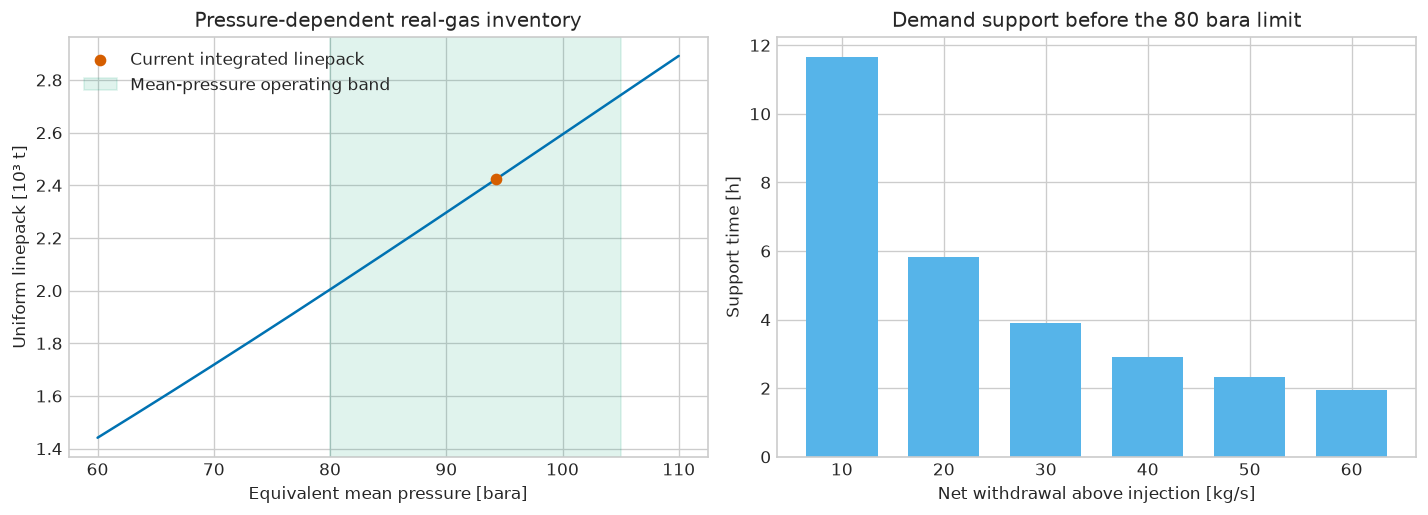

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))

axes[0].plot(
    inventory_pressure_grid_bara,
    uniform_inventory_grid_kg / 1.0e6,
    color="#0072B2",
)
axes[0].scatter(
    [current_mean_pressure_bara],
    [base_inventory["inventory_kg"] / 1.0e6],
    color="#D55E00",
    label="Current integrated linepack",
    zorder=3,
)
axes[0].axvspan(
    minimum_mean_pressure_bara,
    maximum_mean_pressure_bara,
    color="#009E73",
    alpha=0.12,
    label="Mean-pressure operating band",
)
axes[0].set(
    xlabel="Equivalent mean pressure [bara]",
    ylabel="Uniform linepack [10³ t]",
    title="Pressure-dependent real-gas inventory",
)
axes[0].legend()

axes[1].bar(
    deficit_rates_kg_s,
    support_hours,
    width=7.0,
    color="#56B4E9",
)
axes[1].set(
    xlabel="Net withdrawal above injection [kg/s]",
    ylabel="Support time [h]",
    title="Demand support before the 80 bara limit",
)

fig.tight_layout()
plt.show()

## 4. Pack/unpack operating event

The lumped transient obeys the exact pipeline mass balance

$$

\frac{dM}{dt}
=
\dot{m}_\mathrm{in} - \dot{m}_\mathrm{out}

$$

The scenario begins at the native NeqSim steady-state inventory. Export
demand rises from 100 to 140 kg/s between hours 1 and 5. Inlet supply rises
from 100 to 130 kg/s between hours 2 and 6. The mass balance is integrated
with a one-minute step, and $M(P)$ is inverted to obtain equivalent mean
pressure.

This is a linepack-accounting model, not a pressure-wave solver. It is useful
for scheduling screens when the event is slow relative to pressure
equalization and when spatial constraints are checked separately.

In [14]:
time_step_s = 60.0
simulation_hours = 8.0
time_s = np.arange(
    0.0,
    simulation_hours * 3600.0 + time_step_s,
    time_step_s,
)
time_h = time_s / 3600.0

inlet_flow_kg_s = np.full(time_s.size, base_flow_kg_s)
outlet_flow_kg_s = np.full(time_s.size, base_flow_kg_s)

outlet_flow_kg_s[(time_h >= 1.0) & (time_h < 5.0)] = 140.0
inlet_flow_kg_s[(time_h >= 2.0) & (time_h < 6.0)] = 130.0

transient_inventory_kg = np.empty(time_s.size)
transient_inventory_kg[0] = base_inventory["inventory_kg"]

for index in range(1, time_s.size):
    net_flow_kg_s = (
        inlet_flow_kg_s[index - 1]
        - outlet_flow_kg_s[index - 1]
    )
    transient_inventory_kg[index] = (
        transient_inventory_kg[index - 1]
        + net_flow_kg_s * time_step_s
    )

transient_pressure_bara = np.interp(
    transient_inventory_kg,
    uniform_inventory_grid_kg,
    inventory_pressure_grid_bara,
)
usable_linepack_tonnes = (
    transient_inventory_kg - minimum_inventory_kg
) / 1.0e3

integrated_net_mass_kg = np.sum(
    (inlet_flow_kg_s[:-1] - outlet_flow_kg_s[:-1])
    * time_step_s
)
transient_mass_balance_error_kg = (
    transient_inventory_kg[-1]
    - transient_inventory_kg[0]
    - integrated_net_mass_kg
)

transient_summary = pd.DataFrame(
    {
        "Quantity": [
            "Minimum equivalent mean pressure [bara]",
            "Minimum usable linepack [t]",
            "Final inventory change [t]",
            "Mass-balance error [kg]",
        ],
        "Value": [
            transient_pressure_bara.min(),
            usable_linepack_tonnes.min(),
            (
                transient_inventory_kg[-1]
                - transient_inventory_kg[0]
            )
            / 1.0e3,
            transient_mass_balance_error_kg,
        ],
    }
)
display(transient_summary.round(6))

,Quantity,Value
0,Minimum equivalent mean pressure [bara],85.762896
1,Minimum usable linepack [t],167.849391
2,Final inventory change [t],-144.000000
3,Mass-balance error [kg],0.000000


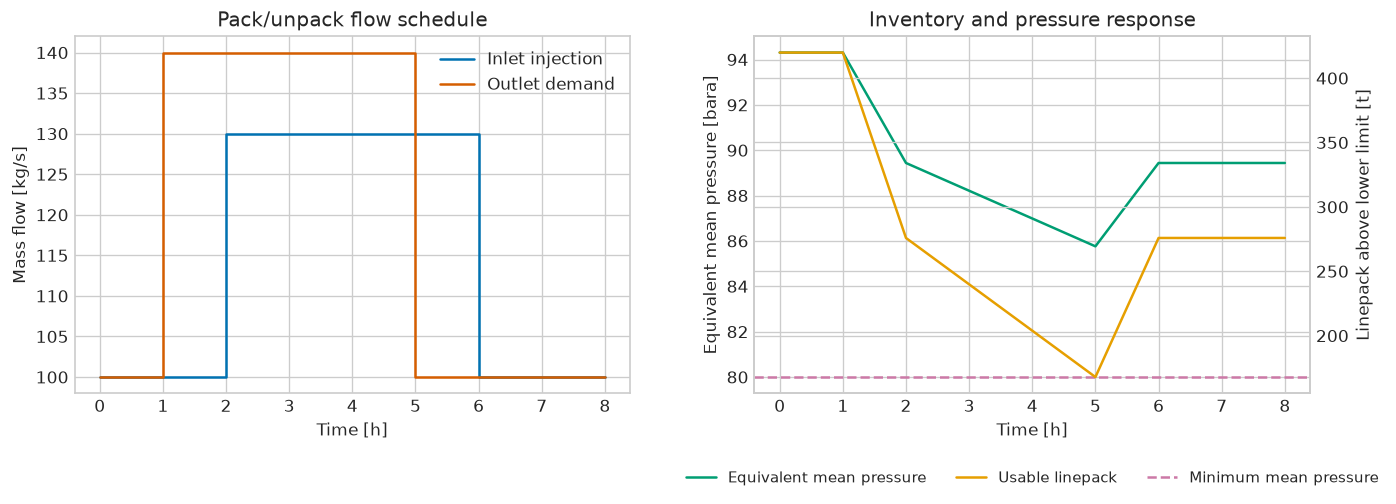

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))

axes[0].step(
    time_h,
    inlet_flow_kg_s,
    where="post",
    label="Inlet injection",
    color="#0072B2",
)
axes[0].step(
    time_h,
    outlet_flow_kg_s,
    where="post",
    label="Outlet demand",
    color="#D55E00",
)
axes[0].set(
    xlabel="Time [h]",
    ylabel="Mass flow [kg/s]",
    title="Pack/unpack flow schedule",
)
axes[0].legend()

pressure_axis = axes[1]
linepack_axis = pressure_axis.twinx()

pressure_line = pressure_axis.plot(
    time_h,
    transient_pressure_bara,
    color="#009E73",
    label="Equivalent mean pressure",
)
pressure_axis.axhline(
    minimum_mean_pressure_bara,
    color="#CC79A7",
    linestyle="--",
    label="Minimum mean pressure",
)
linepack_line = linepack_axis.plot(
    time_h,
    usable_linepack_tonnes,
    color="#E69F00",
    label="Usable linepack",
)

pressure_axis.set(
    xlabel="Time [h]",
    ylabel="Equivalent mean pressure [bara]",
    title="Inventory and pressure response",
)
linepack_axis.set_ylabel("Linepack above lower limit [t]")

lines = pressure_line + linepack_line + [pressure_axis.lines[1]]
labels = [line.get_label() for line in lines]
pressure_axis.legend(
    lines,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=3,
    fontsize=9,
    frameon=False,
)

fig.tight_layout()
plt.show()

## 5. Engineering validation

The checks below are deliberately focused on physical consistency and the
defined operating screen:

- composition and phase state are valid;
- volume-corrected density remains within 1% of the uncorrected EOS identity;
- pressure falls along every pipeline profile;
- outlet pressure decreases as throughput increases;
- the independent Darcy estimate agrees in magnitude with NeqSim;
- linepack and both working margins are positive;
- the pack/unpack mass balance closes; and
- the simulated mean pressure remains inside the inventory interpolation
  range and above the selected lower limit.

In [16]:
assert abs(composition_sum - 1.0) < 1.0e-12
assert set(property_table["phase_count"]) == {1}
assert np.all(np.isfinite(property_table.select_dtypes("number")))
assert np.all(np.diff(property_table["density_kg_m3"]) > 0.0)
assert maximum_density_identity_error < 0.01

for case in pipeline_cases.values():
    assert np.all(np.isfinite(case["pressure_bara"]))
    assert np.all(np.diff(case["pressure_bara"]) <= 1.0e-9)
    assert case["flow_regime"] == "SINGLE_PHASE"

assert np.all(np.diff(pipeline_table["Outlet pressure [bara]"]) < 0.0)
assert darcy_relative_difference < 0.20
assert base_inventory["inventory_kg"] > 0.0
assert available_withdrawal_kg > 0.0
assert packing_headroom_kg > 0.0
assert abs(transient_mass_balance_error_kg) < 1.0e-6
assert transient_pressure_bara.min() >= minimum_mean_pressure_bara
assert transient_pressure_bara.max() <= inventory_pressure_grid_bara.max()

feasible_flows = pipeline_table.loc[
    pipeline_table["Within screen"],
    "Mass flow [kg/s]",
]
maximum_demonstrated_flow_kg_s = feasible_flows.max()

print("All 16 focused engineering assertions passed.")
print(
    "Maximum demonstrated flow within the pressure/velocity screen: "
    f"{maximum_demonstrated_flow_kg_s:.0f} kg/s"
)

All 16 focused engineering assertions passed.
Maximum demonstrated flow within the pressure/velocity screen: 140 kg/s


## Results summary

The final table provides a compact record of the thermodynamic, hydraulic,
inventory, flexibility, and transient results. Values belong to the stated
gas composition, SRK model, geometry, temperature, and operating limits.

In [17]:
results_summary = pd.DataFrame(
    {
        "Result": [
            "NeqSim version",
            "Base outlet pressure",
            "Base pressure drop",
            "Base linepack",
            "Base linepack at stated standard condition",
            "Equivalent current mean pressure",
            "Available withdrawal linepack to 80 bara",
            "Packing headroom to 105 bara",
            "Maximum demonstrated screened flow",
            "Transient minimum mean pressure",
            "Transient mass-balance error",
        ],
        "Value": [
            NEQSIM_VERSION,
            f"{base_case['outlet_pressure_bara']:.2f} bara",
            f"{base_case['pressure_drop_bar']:.2f} bar",
            f"{base_inventory['inventory_kg'] / 1.0e6:.3f} thousand t",
            (
                f"{base_inventory['standard_volume_sm3'] / 1.0e6:.3f} "
                "million Sm³"
            ),
            f"{current_mean_pressure_bara:.2f} bara",
            f"{available_withdrawal_kg / 1.0e3:.1f} t",
            f"{packing_headroom_kg / 1.0e3:.1f} t",
            f"{maximum_demonstrated_flow_kg_s:.0f} kg/s",
            f"{transient_pressure_bara.min():.2f} bara",
            f"{transient_mass_balance_error_kg:.3e} kg",
        ],
    }
)
display(results_summary)

,Result,Value
0,NeqSim version,3.16.0
1,Base outlet pressure,88.39 bara
2,Base pressure drop,11.61 bar
3,Base linepack,2.424 thousand t
4,Base linepack at stated standard condition,3.233 million Sm³
5,Equivalent current mean pressure,94.31 bara
6,Available withdrawal linepack to 80 bara,419.8 t
7,Packing headroom to 105 bara,318.4 t
8,Maximum demonstrated screened flow,140 kg/s
9,Transient minimum mean pressure,85.76 bara


## Interpretation and limitations

- **Thermodynamics matters.** Density is not proportional to pressure alone
  because $Z$ changes across the operating range. NeqSim supplies the
  pressure-dependent real-gas properties used in both hydraulics and
  inventory.
- **Deliverability and linepack are coupled.** Higher flow lowers the outlet
  pressure and slightly redistributes inventory. A valid schedule must satisfy
  local pressure and velocity constraints as well as the total mass balance.
- **Linepack buys time, not supply.** The support-duration chart divides
  available gas mass by a constant net withdrawal. A changing demand or
  injection schedule requires the transient integration.
- **The transient is lumped.** It assumes isothermal operation and maps total
  inventory to an equivalent mean pressure. It does not calculate pressure-wave
  travel, compressor or regulator control, temperature fronts, elevation
  effects, composition fronts, liquid dropout, or spatially varying off-takes.
- **Use a validated dynamic model for decisions.** Operational limits,
  emergency response, contractual delivery, and design-code compliance require
  calibrated geometry, elevations, heat transfer, equipment controls, boundary
  conditions, uncertainty, and independent verification.

## Suggested exercises

1. Replace the gas composition with a hydrogen-enriched or CO₂-rich gas and
   quantify the effect on density, pressure loss, and working linepack.
2. Add an elevation profile and compare pressure margin with the horizontal
   reference case.
3. Sweep pipeline temperature from 0 to 30 °C and plot working linepack.
4. Replace the one-minute lumped balance with multiple control volumes and
   compare the time at which the outlet pressure constraint is reached.
5. Add compressor and delivery-station constraints, then optimize injection
   over a 24-hour demand forecast.

## References

- [NeqSim documentation](https://equinor.github.io/neqsim/)
- [NeqSim `PipeBeggsAndBrills` source and API implementation](https://github.com/equinor/neqsim/blob/master/src/main/java/neqsim/process/equipment/pipeline/PipeBeggsAndBrills.java)
- API RP 14E concepts are relevant to preliminary velocity screening, but the
  fixed velocity limit in this educational example is not a code assessment.
- Osiadacz, A. J. (1987), *Simulation and Analysis of Gas Networks*,
  E. & F. N. Spon.